# Pertemuan 11 — Unsupervised Learning (Clustering)
**Nama Lengkap:** Farraz Dirgham H
**NIM:** 240401020170
**Kelas:** IF405

## Topik
K-Means, Hierarchical Clustering, dan Metode Elbow untuk menentukan jumlah cluster optimal.

Notebook ini menggunakan dataset **Iris** (bawaan `scikit-learn`) sebagai studi kasus clustering tanpa menggunakan label target saat pelatihan (unsupervised).

## 1. Import Library dan Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
sns.set_style("whitegrid")

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y_true = iris.target  # hanya digunakan di akhir untuk validasi, TIDAK dipakai saat clustering

print("Ukuran dataset:", X.shape)
X.head()


Ukuran dataset: (150, 4)


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

## 2. Standarisasi Data
Fitur distandarisasi (mean=0, std=1) agar semua fitur memiliki skala yang setara, penting untuk algoritma berbasis jarak seperti K-Means.

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().round(2)


       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count             150.00            150.00             150.00            150.00
mean               -0.00             -0.00              -0.00             -0.00
std                 1.00              1.00               1.00              1.00
min                -1.87             -2.43              -1.57             -1.45
25%                -0.90             -0.59              -1.23             -1.18
50%                -0.05             -0.13               0.34              0.13
75%                 0.67              0.56               0.76              0.79
max                 2.49              3.09               1.79              1.71

## 3. Metode Elbow untuk Menentukan Jumlah Cluster Optimal
Metode Elbow menghitung *inertia* (within-cluster sum of squares) untuk berbagai nilai k, lalu mencari titik "siku" (elbow) sebagai indikasi jumlah cluster optimal.

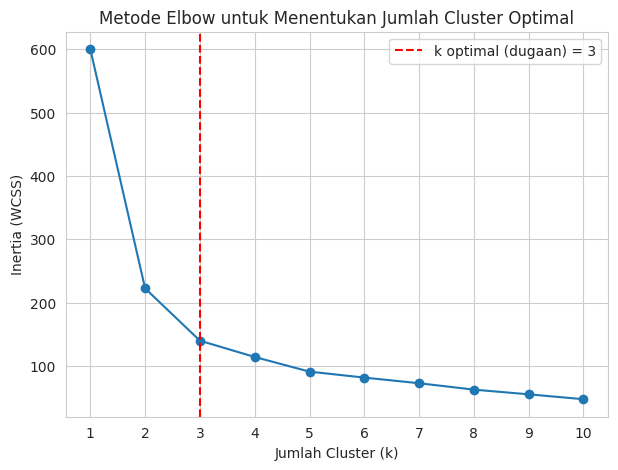

In [3]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.title("Metode Elbow untuk Menentukan Jumlah Cluster Optimal")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(list(k_range))
plt.axvline(x=3, color="red", linestyle="--", label="k optimal (dugaan) = 3")
plt.legend()
plt.show()


In [4]:
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")


k=2: silhouette score = 0.5818
k=3: silhouette score = 0.4599
k=4: silhouette score = 0.3869
k=5: silhouette score = 0.3459
k=6: silhouette score = 0.3171
k=7: silhouette score = 0.3202
k=8: silhouette score = 0.3387
k=9: silhouette score = 0.3424
k=10: silhouette score = 0.3518


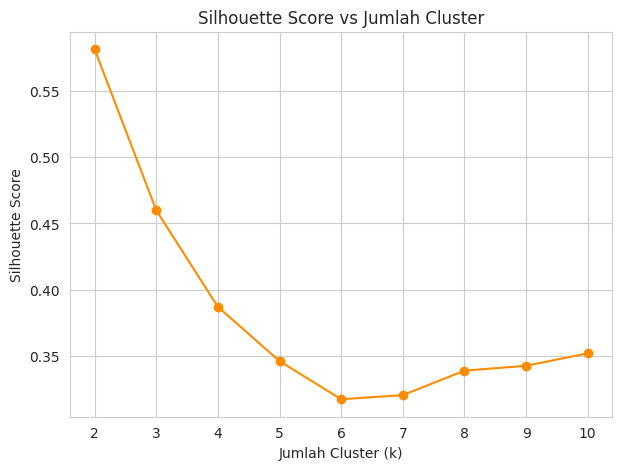

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o", color="darkorange")
plt.title("Silhouette Score vs Jumlah Cluster")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()


Berdasarkan grafik Elbow dan Silhouette Score di atas, **k = 3** dipilih sebagai jumlah cluster optimal — konsisten dengan jumlah kelas asli pada dataset Iris (setosa, versicolor, virginica), meskipun label tersebut tidak digunakan selama proses clustering.

## 4. K-Means Clustering (k=3)

In [6]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_km = kmeans_final.fit_predict(X_scaled)

X_result = X.copy()
X_result["KMeans_Cluster"] = cluster_labels_km

print("Jumlah anggota tiap cluster (K-Means):")
print(X_result["KMeans_Cluster"].value_counts().sort_index())


Jumlah anggota tiap cluster (K-Means):
KMeans_Cluster
0    53
1    50
2    47
Name: count, dtype: int64


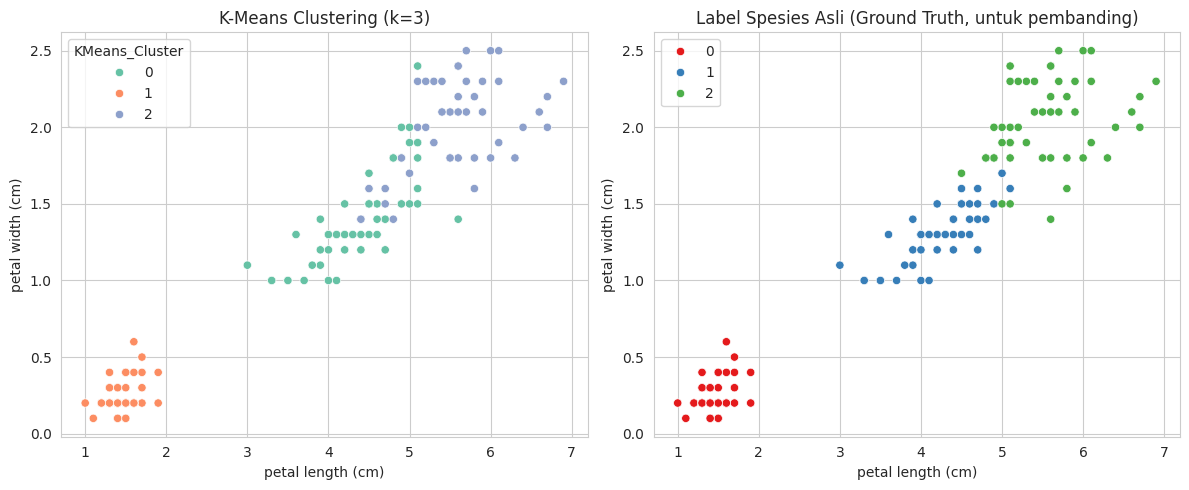

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=X_result, x="petal length (cm)", y="petal width (cm)",
                 hue="KMeans_Cluster", palette="Set2", ax=axes[0])
axes[0].set_title("K-Means Clustering (k=3)")

sns.scatterplot(x=X["petal length (cm)"], y=X["petal width (cm)"], hue=y_true,
                 palette="Set1", ax=axes[1])
axes[1].set_title("Label Spesies Asli (Ground Truth, untuk pembanding)")
plt.tight_layout()
plt.show()


## 5. Hierarchical Clustering (Agglomerative)

In [8]:
agglo = AgglomerativeClustering(n_clusters=3, linkage="ward")
cluster_labels_agglo = agglo.fit_predict(X_scaled)

X_result["Hierarchical_Cluster"] = cluster_labels_agglo
print("Jumlah anggota tiap cluster (Hierarchical):")
print(X_result["Hierarchical_Cluster"].value_counts().sort_index())


Jumlah anggota tiap cluster (Hierarchical):
Hierarchical_Cluster
0    71
1    49
2    30
Name: count, dtype: int64


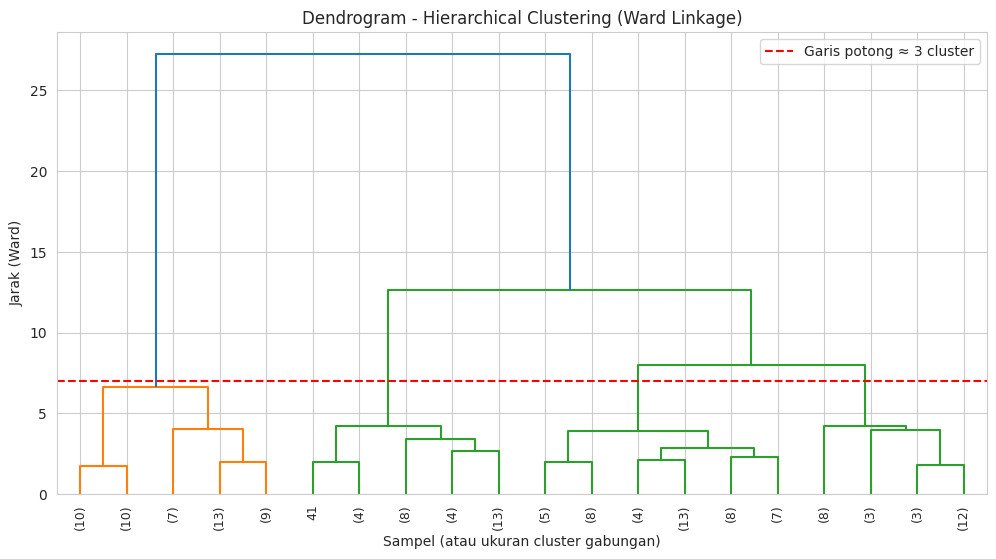

In [9]:
plt.figure(figsize=(12, 6))
Z = linkage(X_scaled, method="ward")
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=90, leaf_font_size=9)
plt.title("Dendrogram - Hierarchical Clustering (Ward Linkage)")
plt.xlabel("Sampel (atau ukuran cluster gabungan)")
plt.ylabel("Jarak (Ward)")
plt.axhline(y=7, color="red", linestyle="--", label="Garis potong ≈ 3 cluster")
plt.legend()
plt.show()


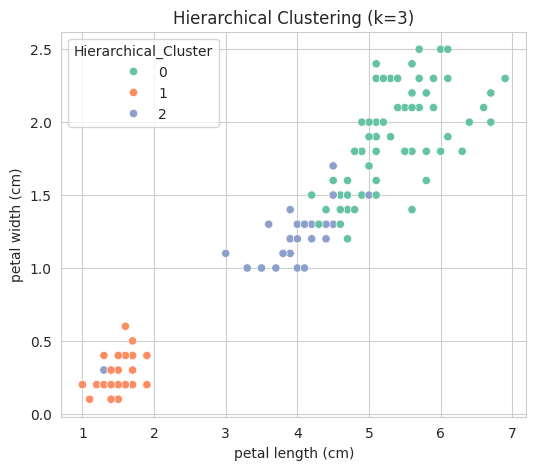

In [10]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=X_result, x="petal length (cm)", y="petal width (cm)",
                 hue="Hierarchical_Cluster", palette="Set2")
plt.title("Hierarchical Clustering (k=3)")
plt.show()


## 6. Perbandingan K-Means vs Hierarchical Clustering

In [11]:
sil_km = silhouette_score(X_scaled, cluster_labels_km)
sil_agglo = silhouette_score(X_scaled, cluster_labels_agglo)

comparison = pd.DataFrame({
    "Metode": ["K-Means", "Hierarchical (Ward)"],
    "Silhouette Score": [sil_km, sil_agglo]
})
comparison


                Metode  Silhouette Score
0              K-Means          0.459948
1  Hierarchical (Ward)          0.446689

In [12]:
cross_tab = pd.crosstab(X_result["KMeans_Cluster"], X_result["Hierarchical_Cluster"])
print("Cross-tabulation antara hasil K-Means dan Hierarchical Clustering:")
cross_tab


Cross-tabulation antara hasil K-Means dan Hierarchical Clustering:


Hierarchical_Cluster   0   1   2
KMeans_Cluster                  
0                     24   0  29
1                      0  49   1
2                     47   0   0

## 7. Kesimpulan

**Apa yang dipelajari:**
Pada pertemuan ini saya mempelajari teknik unsupervised learning untuk pengelompokan data (clustering), khususnya algoritma K-Means dan Hierarchical (Agglomerative) Clustering, serta cara menentukan jumlah cluster optimal menggunakan Metode Elbow dan Silhouette Score.

**Temuan utama:**
Metode Elbow dan Silhouette Score sama-sama mengarahkan pada k=3 sebagai jumlah cluster optimal untuk dataset Iris, yang secara menarik konsisten dengan jumlah spesies bunga asli pada dataset tersebut meskipun label spesies tidak digunakan selama proses clustering. Hasil K-Means dan Hierarchical Clustering menunjukkan pola pengelompokan yang sangat mirip, dengan silhouette score yang berdekatan, mengindikasikan struktur cluster pada data cukup jelas dan konsisten antar metode.

**Keterbatasan / pertanyaan yang muncul:**
- Metode Elbow bersifat cukup subjektif dalam menentukan titik "siku" yang tepat; akan lebih objektif jika dikombinasikan dengan metrik kuantitatif lain seperti Silhouette Score atau Gap Statistic.
- K-Means mengasumsikan cluster berbentuk bulat (spherical) dan berukuran relatif sama — bagaimana performanya jika diterapkan pada dataset dengan bentuk cluster yang tidak beraturan?
- Belum dieksplorasi linkage method lain (single, complete, average) pada Hierarchical Clustering — apakah hasilnya akan berbeda signifikan dibanding Ward linkage yang digunakan di sini?